In [1]:
%matplotlib inline
from matplotlib.pylab import plt

import pandas as pd
import numpy as np
import statsmodels

In [2]:
import statsmodels
print(statsmodels.__version__)
print(np.__version__)
print(pd.__version__)

0.14.6
2.0.2
2.2.2


# Let's start with some informal exploration

In [4]:
air_passengers = pd.read_csv("AirPassengers.csv", header = 0, parse_dates = [0], names = ['Month', 'Passengers'], index_col = 0)

In [5]:
air_passengers.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


### Is this the behavior I want?

In [6]:
air_passengers['1949-01-05':'1949-02-17']

,Passengers
Month,
1949-02-01,118


In [ ]:
# How do we get the desired behavior?

In [7]:
air_passengers['1949-01-05':'1949-02-17']

,Passengers
Month,
1949-02-01,118


### Think about what your data means. Pandas can't do the thinking for you

<Axes: xlabel='Month'>

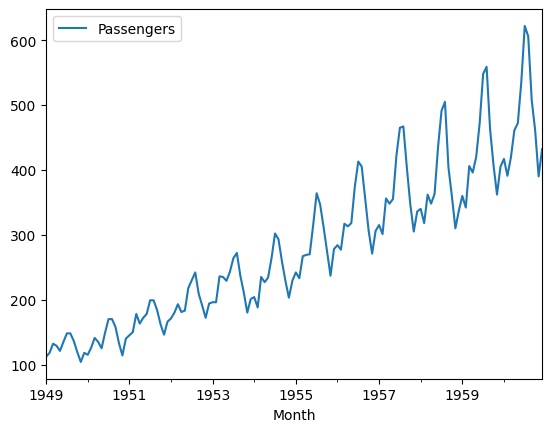

In [8]:
air_passengers.plot()

<Axes: xlabel='Month'>

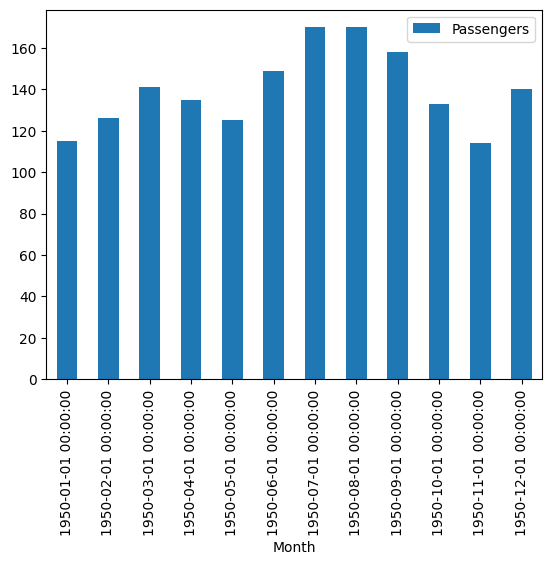

In [13]:
air_passengers.loc['1950'].plot(kind = 'bar')

<Axes: xlabel='Month'>

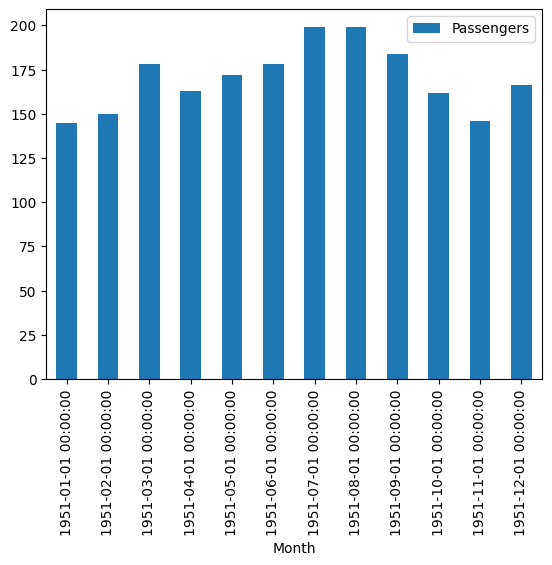

In [15]:
air_passengers.loc['1951'].plot(kind = 'bar')

# Getting a little more formal
### first thing we look at for a time series when we want to use common analysis techniques:
### is it stationary: mean, variance, autocovariance do not depend on time

<Axes: xlabel='Month'>

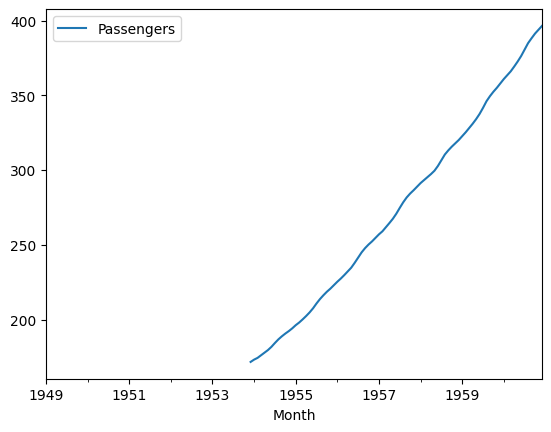

In [16]:
# first test, informally, plot the moving average
# note the ROLLING function
air_passengers.rolling(window = 60).mean().plot()

Text(0, 0.5, 'Variance')

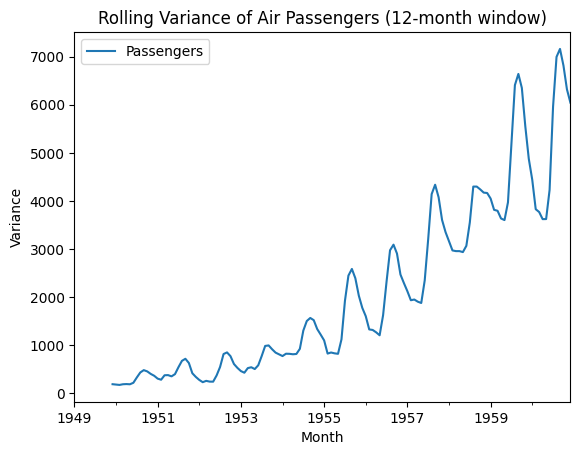

In [17]:
# How can we see whether the variance changes over time?
# Plotting the rolling variance helps visualize if the spread of data changes over time.
air_passengers.rolling(window = 12).var().plot()
plt.title('Rolling Variance of Air Passengers (12-month window)')
plt.xlabel('Month')
plt.ylabel('Variance')

We can visualize changes in variance over time by plotting a rolling variance. I'll add code to plot the rolling variance of air_passengers with a window of 12 months, which is a common choice for monthly data.

In [18]:
# Can you plot the autocorrelation?
from statsmodels.tsa.stattools import acf

Yes, by plotting the autocorrelation function helps to understand how correlated a time series is with its past values. this key step in identifying patterns, such as seasonality or trend, and in determining the appropriate models for time series forecasting.

In [ ]:
# What is the autocorrelation and how can we visualize it?

Autocorrelation measures the correlation between a time series and a lagged version of itself. Essentially, it tells how much an observation at a previous point in time. it helps identify repeating patterns, trends, and seasonality in time series data.

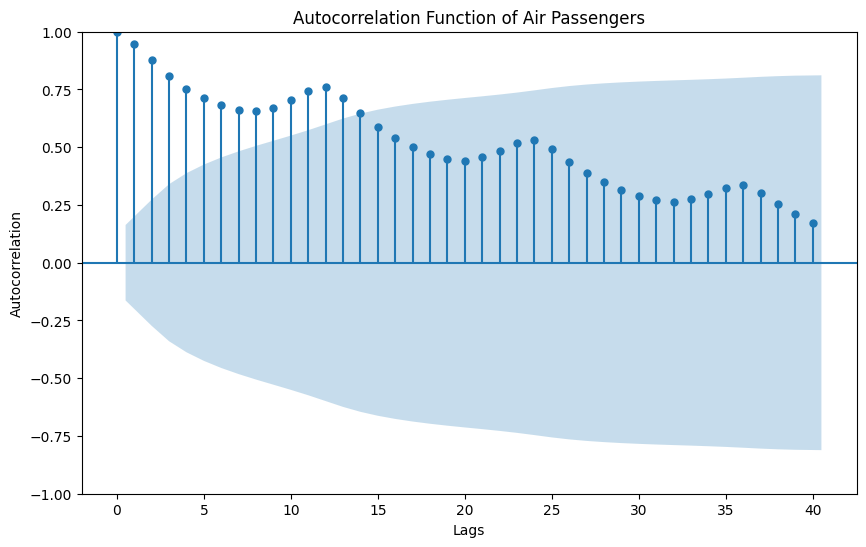

In [20]:
# What is the autocorrelation and how can we visualize it?
from statsmodels.graphics.tsaplots import plot_acf

# Plot the autocorrelation function (ACF)
plt.figure(figsize=(10, 6))
plot_acf(air_passengers.Passengers, lags=40, ax=plt.gca())
plt.title('Autocorrelation Function of Air Passengers')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()

### How can I see whether the autocorrelation is changing over time?

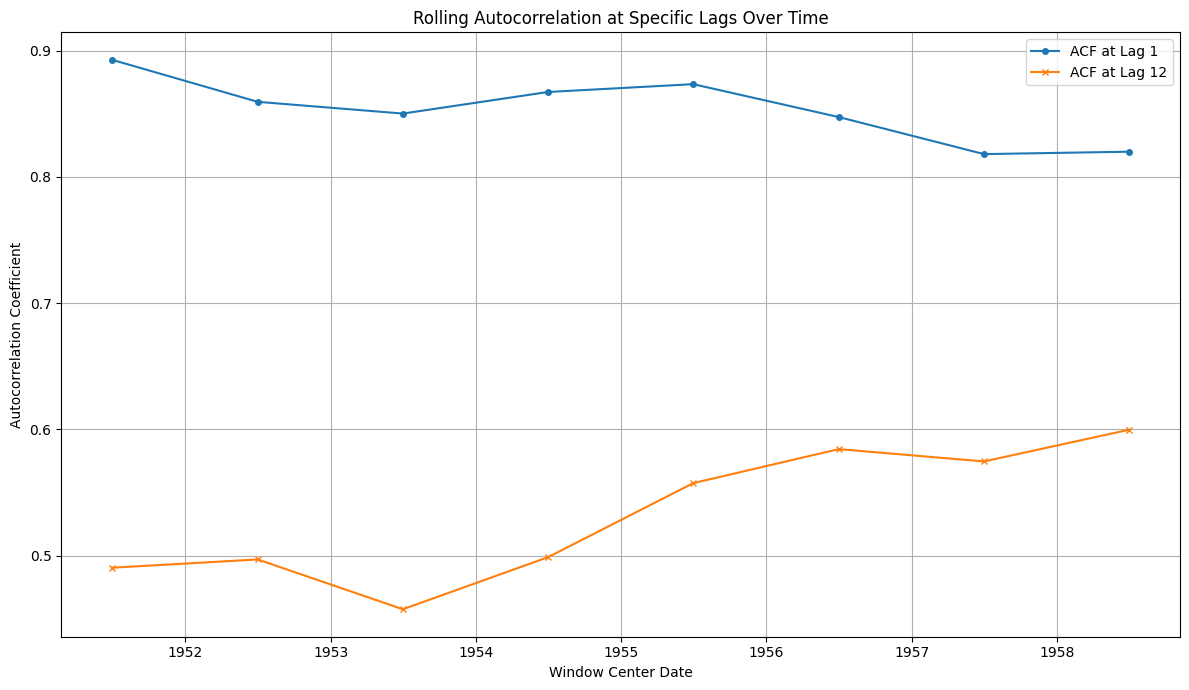

In [22]:
# To see whether the autocorrelation is changing over time, we need to calculate it over rolling windows.
# A single ACF plot gives a static view across the entire series.

# Define window size and step size for rolling ACF calculation
window_size = 60  # e.g., 5 years for monthly data
step_size = 12    # Calculate ACF every year

# Initialize lists to store rolling ACFs and their corresponding time points
rolling_acfs_data = []
window_centers = []

# Loop through the time series to compute ACF for each rolling window
for i in range(0, len(air_passengers) - window_size + 1, step_size):
    window_data = air_passengers.iloc[i : i + window_size]['Passengers']

    # Ensure window_data is not empty and contains finite values before calculating ACF
    if not window_data.empty and not window_data.isnull().all():
        # Calculate ACF for the current window. nlags should be less than nobs / 2.
        # Using fft=True for potentially faster computation.
        acfv = acf(window_data, nlags=min(30, len(window_data) // 2 - 1), fft=True, missing='conservative')
        rolling_acfs_data.append(acfv)
        window_centers.append(air_passengers.index[i + window_size // 2])

# Visualize the rolling ACFs if data was collected
if rolling_acfs_data:
    # Create a DataFrame for easier plotting, with lags as columns
    # The length of acfv might vary slightly depending on the window_data size and nlags,
    # so we'll pad with NaNs if necessary for DataFrame creation or take the minimum length.
    max_lags = max(len(acfs) for acfs in rolling_acfs_data)
    padded_acfs = [np.pad(acfs, (0, max_lags - len(acfs)), 'constant', constant_values=np.nan) for acfs in rolling_acfs_data]

    rolling_acfs_df = pd.DataFrame(padded_acfs, index=window_centers)
    rolling_acfs_df.columns = [f'Lag {j}' for j in range(max_lags)]

    plt.figure(figsize=(12, 7))
    # Plot ACF for Lag 1 (short-term persistence)
    plt.plot(rolling_acfs_df['Lag 1'], label='ACF at Lag 1', marker='o', markersize=4)
    # Plot ACF for Lag 12 (annual seasonality for monthly data)
    if 'Lag 12' in rolling_acfs_df.columns:
        plt.plot(rolling_acfs_df['Lag 12'], label='ACF at Lag 12', marker='x', markersize=4)

    plt.title('Rolling Autocorrelation at Specific Lags Over Time')
    plt.xlabel('Window Center Date')
    plt.ylabel('Autocorrelation Coefficient')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data to compute rolling ACFs with the given window size and step size.")

### Always have to make judgment calls

<Axes: xlabel='Month'>

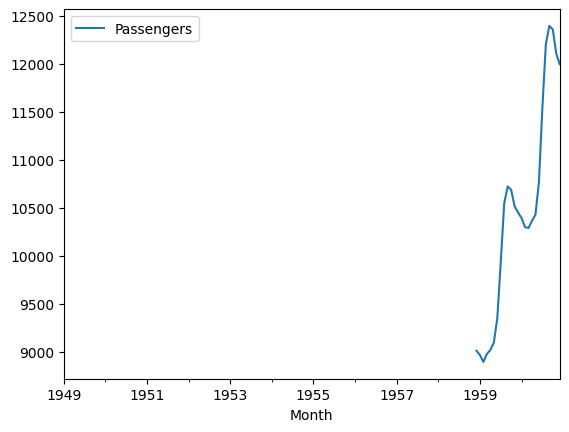

In [23]:
# How should you size your window?
air_passengers.rolling(window = 120).var().plot()

# And now let's make it formal

In [24]:
# next more formally apply the Augmented Dickey-Fuller test
from statsmodels.tsa.stattools import adfuller
adfuller(air_passengers.Passengers, autolag = 'AIC', regression = 'ct')

(np.float64(-2.100781813844672),
 np.float64(0.5456589343124537),
 13,
 130,
 {'1%': np.float64(-4.030152423759672),
  '5%': np.float64(-3.444817634956759),
  '10%': np.float64(-3.1471816659080565)},
 np.float64(993.2814778200581))

### What do these numbers mean? Let's take a look at statsmodels documentation

In [ ]:
# Can we write a function to output these #s sensibly?
# Check out statsmodels.sourceforge.net/devel/generated/statsmodels.tsa.stattools.adfuller.html

In [26]:
# Can we write a function to output these #s sensibly?
# Check out statsmodels.sourceforge.net/devel/generated/statsmodels.tsa.stattools.adfuller.html

def adf_test_results(timeseries):
    print('Results of Augmented Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
       dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)
    if dftest[1] <= 0.05:
        print("\nConclusion: The time series is likely stationary (reject H0).")
    else:
        print("\nConclusion: The time series is likely non-stationary (fail to reject H0).")

adf_test_results(air_passengers['Passengers'])

Results of Augmented Dickey-Fuller Test:
Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64

Conclusion: The time series is likely non-stationary (fail to reject H0).


# Where do we go from here?

In [ ]:
# Are we stuck not doing any analysis now that our time series is not stationary? Hint: no.
# How can we make it stationary?
# Why is it non-stationary (2 reasons)

There are two main reasons why a time series is typically non-stationary:

**Presence of a Trend:** The mean of the series changes over time. For example, our 'Air Passengers' data shows a clear upward trend, meaning the average number of passengers is increasing over the years. We observed this in the air_passengers.plot() output and the rolling mean plot.

**Presence of Seasonality:** The variance of the series changes over time, or there are regular, predictable patterns that recur over a fixed period. In our case, the air_passengers data clearly shows a seasonal pattern (e.g., higher travel during certain months each year), and the rolling variance plot indicated that the variability was also increasing over time.

To make a non-stationary series stationary, we use techniques that address these issues:

**Variance Stabilization:** Taking a log or power transformation can help stabilize the variance.

**Detrending:** Removing the trend, either by subtracting a rolling mean or by fitting and subtracting a regression line.

**Differencing:** Subtracting the observation from the previous time step is a very effective way to remove both trend and seasonality.

**Seasonal Decomposition:** Explicitly separating the series into trend, seasonal, and residual components allows you to work with the stationary residual component.

<Axes: xlabel='Month'>

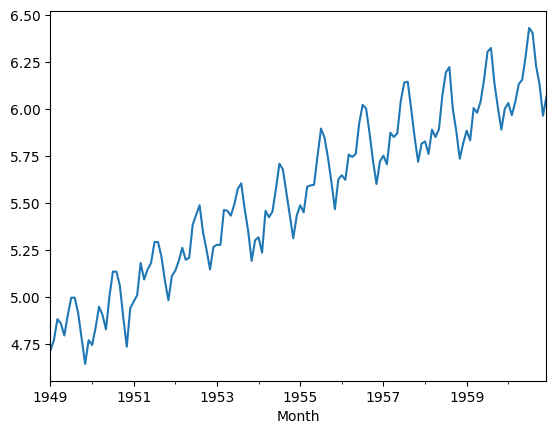

In [27]:
# One method to get rid of time varying variance is to do a power or log transformation that punishes larger values
# more than smaller values
log_passengers = air_passengers.Passengers.apply(lambda x: np.log(x))
log_passengers.plot()

<Axes: xlabel='Month'>

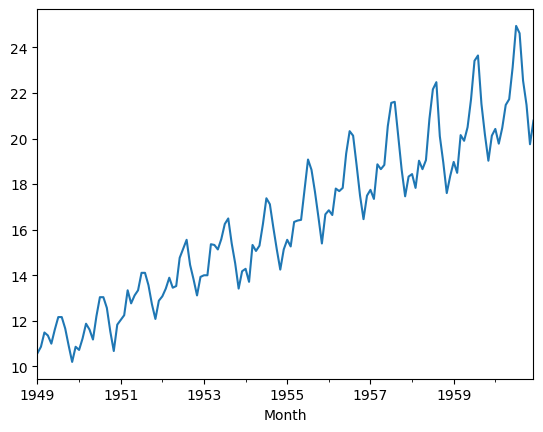

In [28]:
# Let's see what that looks like as a power transformation
rt_passengers = air_passengers.Passengers.apply(lambda x: x**.5)
rt_passengers.plot()

<Axes: xlabel='Month'>

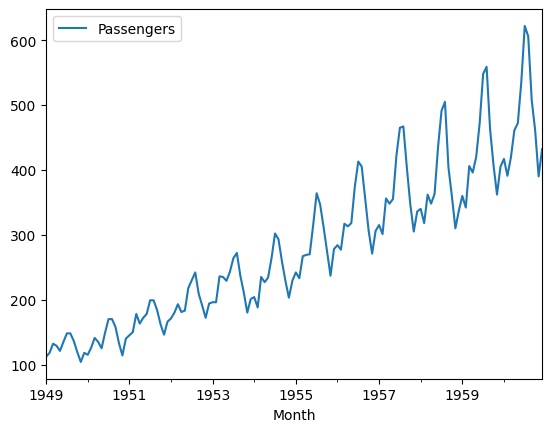

In [29]:
# This reduces the variance in variance as opposed to the original trend
air_passengers.plot()

<Axes: xlabel='Month'>

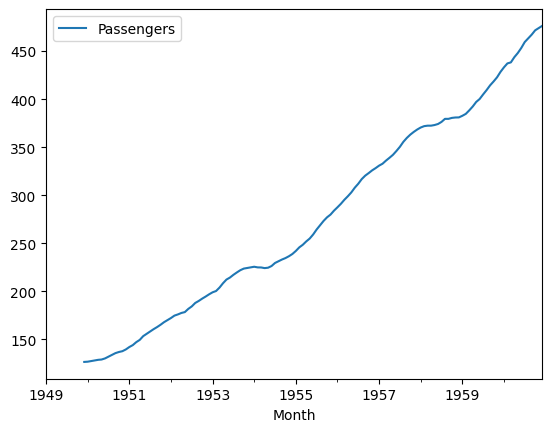

In [30]:
# However there is still a trend we need to remove
# Let's calculate a rolling mean
# Experiment with window size
air_passengers.rolling(window = 12).mean().plot()

<Axes: xlabel='Month'>

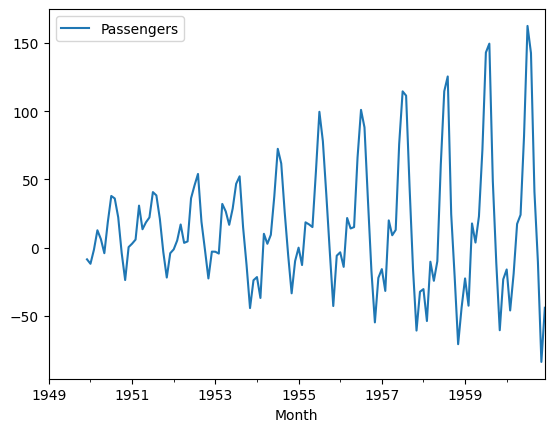

In [31]:
# What if we subtract this rolling mean from the original series?
rolling_mean = air_passengers.rolling(window = 12).mean()
passengers_detrended = air_passengers - rolling_mean
passengers_detrended.plot()

<Axes: xlabel='Month'>

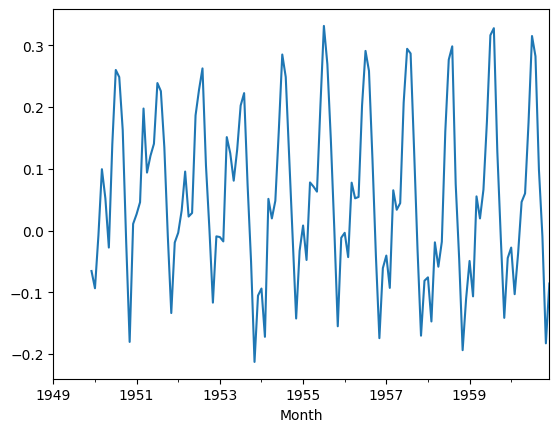

In [32]:
# Exercise: try detrending after taking the log. How does that look?
log_rolling_mean = log_passengers.rolling(window = 12).mean()
log_detrended = log_passengers - log_rolling_mean
log_detrended.plot()

<Axes: xlabel='Month'>

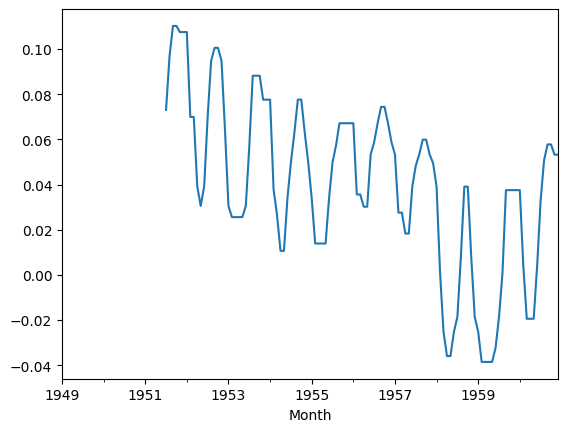

In [33]:
log_detrended.rolling(20).median().plot()

/tmp/ipython-input-1272320432.py:4: RuntimeWarning: invalid value encountered in log
  log_detrended2 = passengers_detrended.Passengers.apply(lambda x: np.log(x))


<Axes: xlabel='Month'>

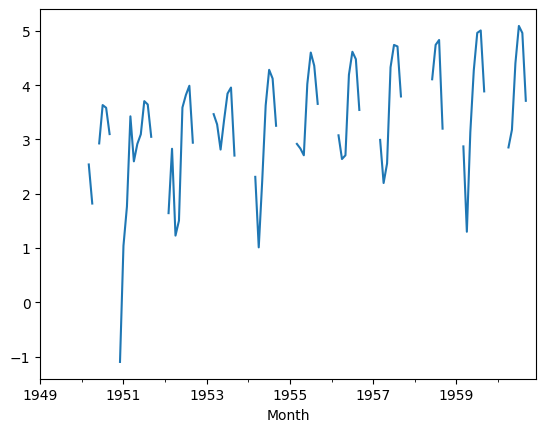

In [34]:
# Exercise: try detrending before taking the log. How does that look?
rolling_mean = air_passengers.rolling(window = 12).mean()
passengers_detrended = air_passengers - rolling_mean
log_detrended2 = passengers_detrended.Passengers.apply(lambda x: np.log(x))
log_detrended2.plot()

### Why didn't that work?

<Axes: xlabel='Month'>

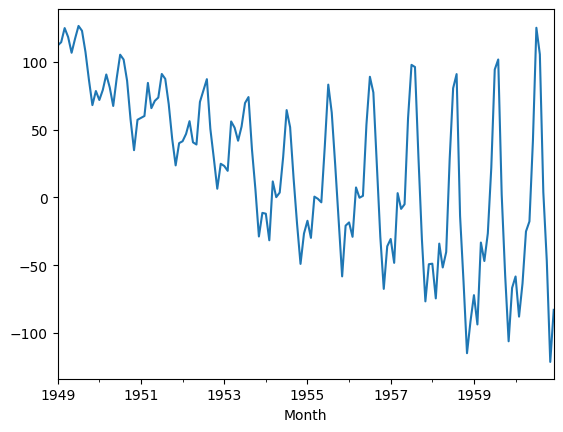

In [35]:
# Now let's use a regression rather than a rolling mean to detrend
from statsmodels.regression.linear_model import OLS
model = OLS(air_passengers.Passengers.values, list(range(len(air_passengers.values))))
result = model.fit()
result.params
fit = pd.Series(result.predict(list(range(len(air_passengers.values)))), index = air_passengers.index)

passengers_detrended = air_passengers.Passengers - fit
passengers_detrended.plot()

<Axes: xlabel='Month'>

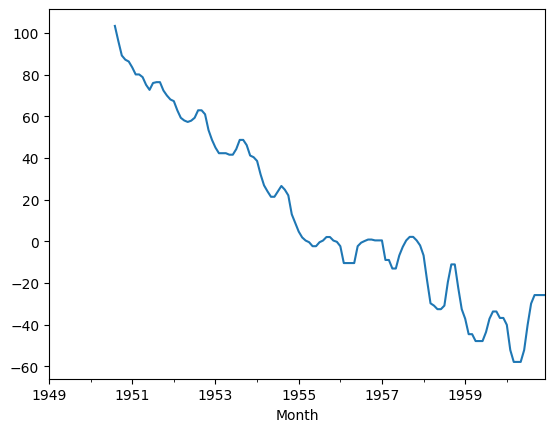

In [36]:
passengers_detrended.rolling(20).median().plot()

### What worked better, the rolling average or the regression? Why?

# Seasonality

### Differencing

<Axes: xlabel='Month'>

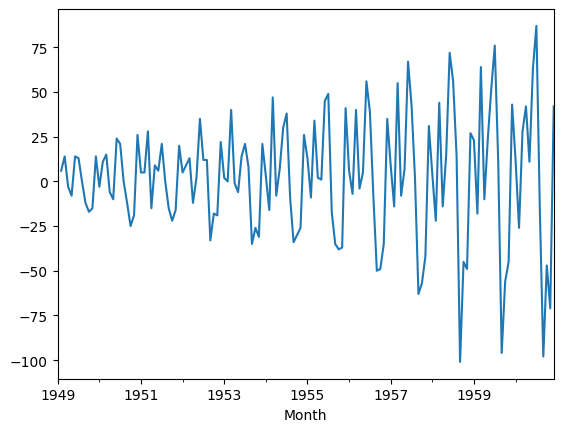

In [37]:
(air_passengers.Passengers - air_passengers.Passengers.shift()).plot()

<Axes: xlabel='Month'>

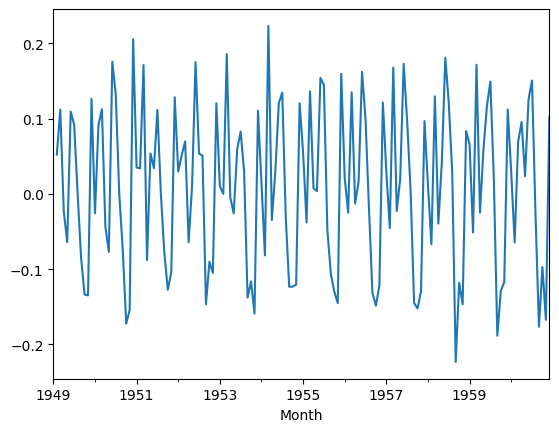

In [38]:
# One common technique is differencing, let's start with log_passengers
log_passengers_diff = log_passengers - log_passengers.shift()
log_passengers_diff.plot()

In [ ]:
# Let's again test for stationarity with a gut level check.
# And let's write a function to do it since this seems like something we'll have to do a lot

In [40]:
log_passengers = log_passengers.to_timestamp()

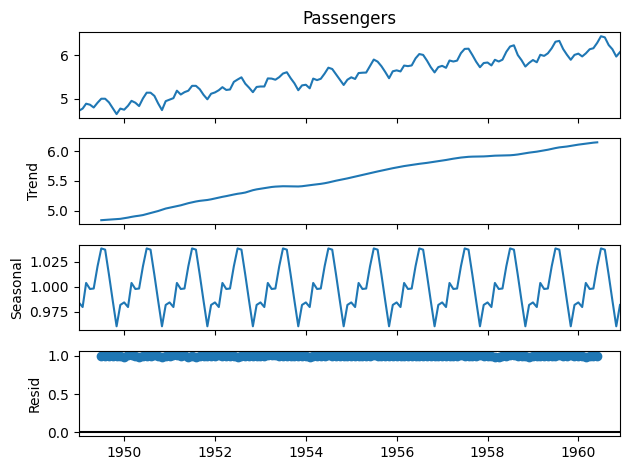

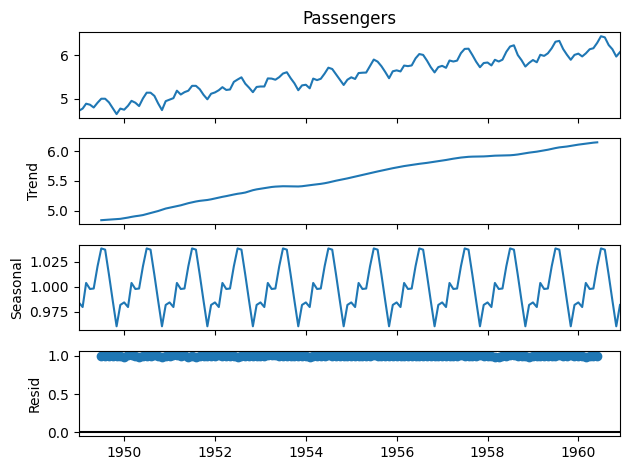

In [40]:
from statsmodels.tsa.seasonal import seasonal_decompose

log_passengers.interpolate(inplace = True)
decomposition = seasonal_decompose(log_passengers, model = 'multiplicative')
decomposition.plot()

### Seasonal or multiplicative time series?

In [ ]:
# When to use which?

In [41]:
decomposition = seasonal_decompose(log_passengers, model = 'multiplicative')
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

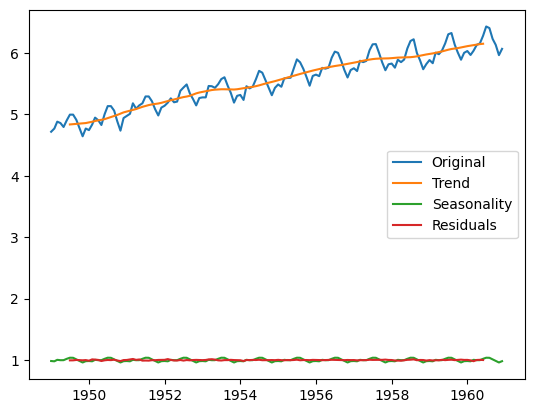

In [42]:
plt.plot(log_passengers, label='Original')
plt.plot(trend, label='Trend')
plt.plot(seasonal,label='Seasonality')
plt.plot(residual, label='Residuals')
plt.legend(loc = 'best')

# Let's walk through seasonal_decompose

In [75]:
from statsmodels.compat.python import lmap
import numpy as np
from pandas.core.nanops import nanmean as pd_nanmean
from statsmodels.tsa.filters.filtertools import convolution_filter
from statsmodels.tsa.tsatools import freq_to_period

In [61]:
x = log_passengers
# _pandas_wrapper, pfreq = _maybe_get_pandas_wrapper_freq(x) # This line caused an error and is removed
model = "multiplicative"

In [45]:
x = np.asanyarray(x).squeeze()

In [46]:
nobs = len(x)

In [47]:
nobs

144

In [49]:
if not np.all(np.isfinite(x)):
    raise ValueError("This function does not handle missing values")
model = "multiplicative" # Re-assign model to its expected string value
if model.startswith('m'):
    if np.any(x <= 0):
        raise ValueError("Multiplicative seasonality is not appropriate "
                             "for zero and negative values")

In [76]:
freq = 12 # Explicitly set frequency to 12 for monthly data, as pfreq is not available.
# Original conditional logic for freq determination is commented out as it caused NameError due to missing pfreq.
# if freq is None:
#     if pfreq is not None:
#         pfreq = freq_to_period(pfreq)
#         freq = pfreq
#     else:
#         raise ValueError("You must specify a freq or x must be a "
#                          "pandas object with a timeseries index with"
#                          "a freq not set to None")

In [57]:
freq

In [73]:
filt = None
two_sided = True
if filt is None:
    if freq % 2 == 0:  # split weights at ends
        filt = np.array([.5] + [1] * (freq - 1) + [.5]) / freq
    else:
        filt = np.repeat(1./freq, freq)

nsides = int(two_sided) + 1
trend = convolution_filter(x, filt, nsides)


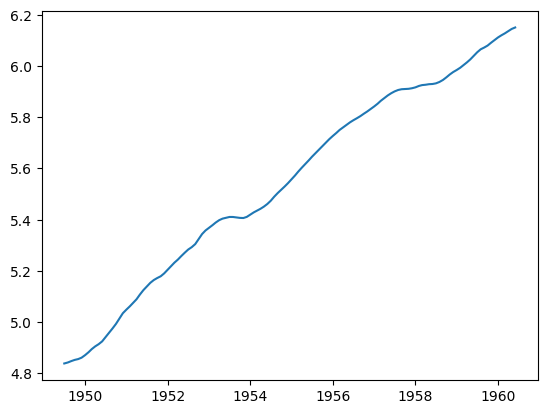

In [59]:
plt.plot(trend)

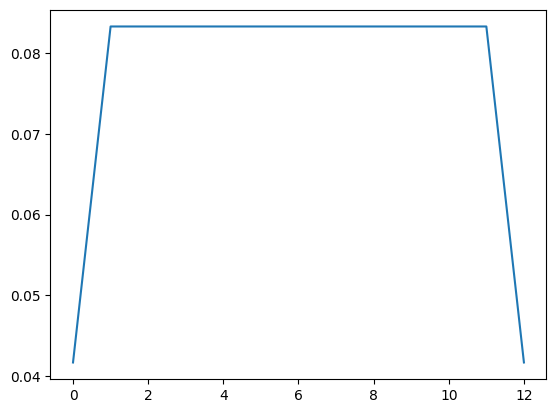

In [74]:
plt.plot(filt)

In [65]:
if model.startswith('m'):
    detrended = x / trend
else:
    detrended = x - trend

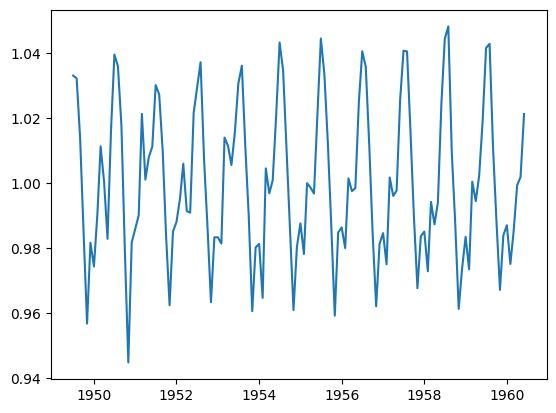

In [66]:
plt.plot(detrended)

In [67]:
def seasonal_mean(x, freq):
    """
    Return means for each period in x. freq is an int that gives the
    number of periods per cycle. E.g., 12 for monthly. NaNs are ignored
    in the mean.
    """
    return np.array([pd_nanmean(x[i::freq]) for i in range(freq)])

In [83]:
period_averages = seasonal_mean(detrended.values, freq)

if model.startswith('m'):
    period_averages /= np.mean(period_averages)
else:
    period_averages -= np.mean(period_averages)

seasonal = np.tile(period_averages, nobs // freq + 1)[:nobs]

if model.startswith('m'):
    resid = x / seasonal / trend
else:
    resid = detrended - seasonal

Text(0, 0.5, 'Seasonal Factor')

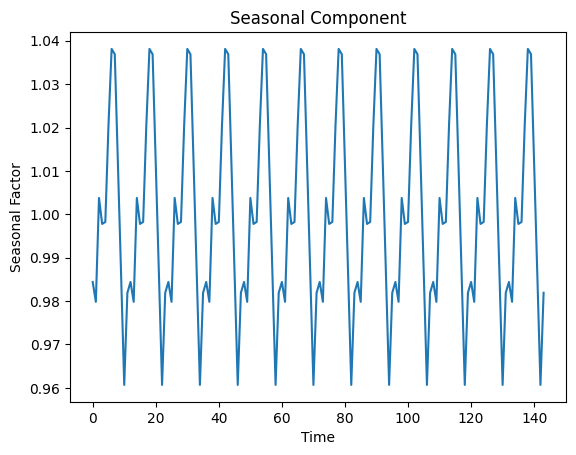

In [84]:
plt.plot(seasonal)
plt.title('Seasonal Component')
plt.xlabel('Time')
plt.ylabel('Seasonal Factor')

Text(0, 0.5, 'Residual')

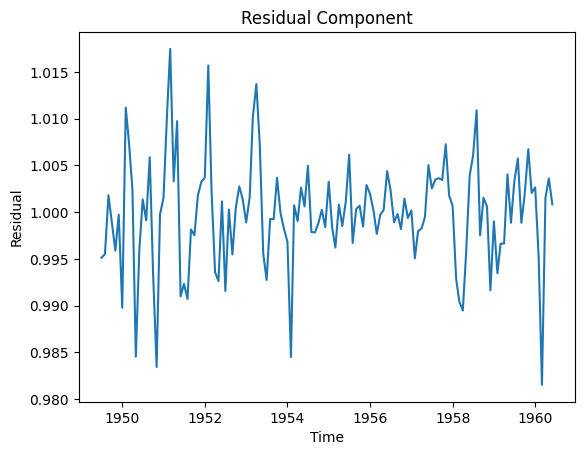

In [85]:
plt.plot(resid)
plt.title('Residual Component')
plt.xlabel('Time')
plt.ylabel('Residual')

In [78]:
filt = None
two_sided = True
if filt is None:
    if freq % 2 == 0:  # split weights at ends
        filt = np.array([.5] + [1] * (freq - 1) + [.5]) / freq
    else:
        filt = np.repeat(1./freq, freq)

nsides = int(two_sided) + 1
trend = convolution_filter(x, filt, nsides)

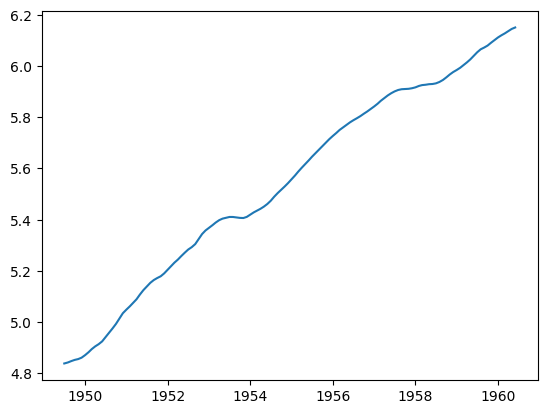

In [79]:
plt.plot(trend)

In [80]:
if model.startswith('m'):
    detrended = x / trend
else:
    detrended = x - trend

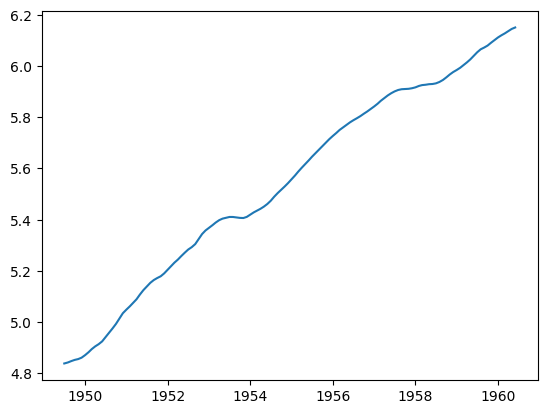

In [86]:
plt.plot(trend)